In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

## . Load Models 

In [27]:
!pip install split-folders

In [28]:
import splitfolders

input_folder = "/kaggle/input/sugarcane-plant-diseases-dataset/Sugarcane_leafs"
splitfolders.ratio(input_folder, output="/kaggle/working/sugarcanedisease", seed=42, ratio=(0.7, 0.15, 0.15), group_prefix=None)

Copying files: 19926 files [02:27, 135.02 files/s]


In [29]:
# Import standard libraries  
import os  
import numpy as np  
import matplotlib.pyplot as plt  
from tqdm import tqdm  
  
# PyTorch libraries  
import torch  
from torchvision import datasets, transforms  
from torch.utils.data import DataLoader  
  
# Transformer models  
from transformers import ViTForImageClassification, SwinForImageClassification  
  
# Ensure reproducibility  
torch.manual_seed(42)  
np.random.seed(42)  
  
# Set up device (GPU if available)  
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')  
print(f'Using device: {device}') 

Using device: cuda


In [31]:
# Set up device (GPU if available)  
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')  
print(f'Using device: {device}')

Using device: cuda


## LOading the trained models on the same dataset

In [33]:
import torch  
from transformers import ViTForImageClassification, SwinForImageClassification  
  
# Paths to the saved model weights  
vit_model_path = '/kaggle/input/ensemblemodel/pytorch/default/1/vit_sugarcane_disease_detection.pth'  

  
# Load ViT model  
vit_model = ViTForImageClassification.from_pretrained(  
    'google/vit-base-patch16-224-in21k',  
    num_labels=6,  # Ensure num_labels is set correctly  
    ignore_mismatched_sizes=True  # Add if necessary  
)  
vit_model.load_state_dict(torch.load(vit_model_path, map_location=device))  
vit_model.to(device)  
vit_model.eval()

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

In [34]:
swin_model_path = '/kaggle/input/ensemblemodel/pytorch/default/1/swin_sugarcane_disease_detection.pth'  
# Load Swin Transformer model  
swin_model = SwinForImageClassification.from_pretrained(  
    'microsoft/swin-base-patch4-window7-224',  
    num_labels=6,  
    ignore_mismatched_sizes=True  
)  
swin_model.load_state_dict(torch.load(swin_model_path, map_location=device))  
swin_model.to(device)  
swin_model.eval()  

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/352M [00:00<?, ?B/s]

Some weights of SwinForImageClassification were not initialized from the model checkpoint at microsoft/swin-base-patch4-window7-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([6]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 1024]) in the checkpoint and torch.Size([6, 1024]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


SwinForImageClassification(
  (swin): SwinModel(
    (embeddings): SwinEmbeddings(
      (patch_embeddings): SwinPatchEmbeddings(
        (projection): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
      )
      (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): SwinEncoder(
      (layers): ModuleList(
        (0): SwinStage(
          (blocks): ModuleList(
            (0): SwinLayer(
              (layernorm_before): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
              (attention): SwinAttention(
                (self): SwinSelfAttention(
                  (query): Linear(in_features=128, out_features=128, bias=True)
                  (key): Linear(in_features=128, out_features=128, bias=True)
                  (value): Linear(in_features=128, out_features=128, bias=True)
                  (dropout): Dropout(p=0.0, inplace=False)
                )
                (output): SwinSelfOutput(

In [35]:
import os  
import torch  
from torchvision import datasets, transforms  
  
# Define data directories  
data_dir = '/kaggle/working/sugarcanedisease'  
train_dir = os.path.join(data_dir, 'train')  
val_dir = os.path.join(data_dir, 'val')  
test_dir = os.path.join(data_dir, 'test')  
  
# Define image size and batch size  
IMG_SIZE = (224, 224)  
BATCH_SIZE = 8  
  
# Define data transformations  
# Corresponding to Keras ImageDataGenerator parameters  
data_transforms = {  
    'train': transforms.Compose([  
        transforms.Resize(IMG_SIZE),  
        transforms.RandomRotation(90),  
        transforms.RandomHorizontalFlip(),  
        transforms.RandomVerticalFlip(),  
        transforms.RandomAffine(degrees=0, scale=(0.8, 1.2)),  
        transforms.ToTensor(),  
        # No need for rescale=1./255 because ToTensor() does that  
    ]),  
    'val': transforms.Compose([  
        transforms.Resize(IMG_SIZE),  
        transforms.ToTensor(),  
        # No need for rescale=1./255 because ToTensor() does that  
    ]),  
    'test': transforms.Compose([  
        transforms.Resize(IMG_SIZE),  
        transforms.ToTensor(),  
        # No need for rescale=1./255 because ToTensor() does that  
    ]),  
}  
  
# Create datasets using ImageFolder  
train_dataset = datasets.ImageFolder(train_dir, transform=data_transforms['train'])  
val_dataset = datasets.ImageFolder(val_dir, transform=data_transforms['val'])  
test_dataset = datasets.ImageFolder(test_dir, transform=data_transforms['test'])  
  
# Create DataLoaders  
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)  
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)  
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4) 

In [36]:
import torch.nn.functional as F  
  
def ensemble_predict(inputs):  
    # Get outputs from ViT model  
    vit_outputs = vit_model(inputs).logits  # Shape: [batch_size, num_classes]  
      
    # Get outputs from Swin Transformer model  
    swin_outputs = swin_model(inputs).logits  # Shape: [batch_size, num_classes]  
      
    # Apply softmax to get probabilities  
    vit_probs = F.softmax(vit_outputs, dim=1)  
    swin_probs = F.softmax(swin_outputs, dim=1)  
      
    # Average the probabilities  
    avg_probs = (vit_probs + swin_probs) / 2  
      
    # Get the final predictions  
    _, ensemble_preds = torch.max(avg_probs, dim=1)  
      
    return ensemble_preds, avg_probs 

In [79]:
ensemble_config = {
    "ensemble_method": "softmax_probability_averaging",
    "base_models": ["Vision Transformer", "Swin Transformer"],
    "num_classes": 6,
    "class_names": [
        "Red Rot",
        "Rust",
        "Yellow Leaf",
        "Bacterial Blight",
        "Healthy",
        "Mosaic"
    ]}

torch.save(
    ensemble_config,
    "/kaggle/working/ensemble_config.pth"
)

print("✅ Ensemble configuration saved")

✅ Ensemble configuration saved


In [38]:
# Initialize counters  
ensemble_correct = 0  
total_samples = 0  
  
# Keep track of all labels and predictions for metrics  
all_labels = []  
all_preds = []  
  
model_outputs = []  
  
# Evaluation loop  
with torch.no_grad():  
    for inputs, labels in tqdm(test_loader, desc='Evaluating Ensemble'):  
        inputs = inputs.to(device)  
        labels = labels.to(device)  
          
        # Get ensemble predictions  
        ensemble_preds, avg_probs = ensemble_predict(inputs)  
          
        # Update counters  
        ensemble_correct += (ensemble_preds == labels).sum().item()  
        total_samples += labels.size(0)  
          
        # Collect labels and predictions for metrics  
        all_labels.extend(labels.cpu().numpy())  
        all_preds.extend(ensemble_preds.cpu().numpy())  
        model_outputs.extend(avg_probs.cpu().numpy())  
          
# Calculate accuracy  
ensemble_accuracy = ensemble_correct / total_samples  
print(f'Ensemble Model Accuracy: {ensemble_accuracy:.4f}')

Evaluating Ensemble: 100%|██████████| 375/375 [01:28<00:00,  4.26it/s]

Ensemble Model Accuracy: 0.9696


## VIT

In [44]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

def evaluate_model(model, dataloader, model_name="Model"):
    y_true, y_pred = [], []

    model.eval()
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images).logits
            preds = torch.argmax(outputs, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    print(f"\n{model_name} Classification Report")
    print(classification_report(y_true, y_pred, digits=4))

    acc = accuracy_score(y_true, y_pred)
    print(f"{model_name} Accuracy: {acc:.4f}")

    return y_true, y_pred, acc

In [45]:
vit_y_true, vit_y_pred, vit_acc = evaluate_model(vit_model, test_loader, "ViT")


ViT Classification Report
              precision    recall  f1-score   support

           0     0.9716    0.9972    0.9842       720
           1     0.9539    0.9660    0.9599       471
           2     0.9435    0.9616    0.9525       417
           3     0.9651    0.9486    0.9568       467
           4     0.9592    0.9634    0.9613       464
           5     0.9673    0.9099    0.9377       455

    accuracy                         0.9613      2994
   macro avg     0.9601    0.9578    0.9587      2994
weighted avg     0.9613    0.9613    0.9611      2994

ViT Accuracy: 0.9613


## SWIN

In [46]:
swin_y_true, swin_y_pred, swin_acc = evaluate_model(swin_model, test_loader, "Swin Transformer")


Swin Transformer Classification Report
              precision    recall  f1-score   support

           0     0.9904    0.9986    0.9945       720
           1     0.9756    0.9342    0.9544       471
           2     0.9314    0.9760    0.9532       417
           3     0.9781    0.9550    0.9664       467
           4     0.9479    0.9806    0.9640       464
           5     0.9550    0.9319    0.9433       455

    accuracy                         0.9656      2994
   macro avg     0.9630    0.9627    0.9626      2994
weighted avg     0.9659    0.9656    0.9655      2994

Swin Transformer Accuracy: 0.9656


In [48]:
def evaluate_ensemble(vit_model, swin_model, dataloader):
    y_true, y_pred = [], []

    vit_model.eval()
    swin_model.eval()

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            vit_logits = vit_model(images).logits
            swin_logits = swin_model(images).logits

            avg_logits = (vit_logits + swin_logits) / 2
            preds = torch.argmax(avg_logits, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    print("\nEnsemble Classification Report")
    print(classification_report(y_true, y_pred, digits=4))

    acc = accuracy_score(y_true, y_pred)
    print(f"Ensemble Accuracy: {acc:.4f}")

    return y_true, y_pred, acc

## Ensemble

In [49]:
ens_y_true, ens_y_pred, ens_acc = evaluate_ensemble(vit_model, swin_model, test_loader)


Ensemble Classification Report
              precision    recall  f1-score   support

           0     0.9823    1.0000    0.9911       720
           1     0.9720    0.9597    0.9658       471
           2     0.9598    0.9736    0.9667       417
           3     0.9825    0.9593    0.9707       467
           4     0.9538    0.9784    0.9660       464
           5     0.9660    0.9363    0.9509       455

    accuracy                         0.9706      2994
   macro avg     0.9694    0.9679    0.9685      2994
weighted avg     0.9707    0.9706    0.9705      2994

Ensemble Accuracy: 0.9706


In [50]:
def evaluate_weighted_average(vit_model, swin_model, dataloader, vit_weight=0.6, swin_weight=0.4, device="cuda"):
    y_true, y_pred = [], []

    vit_model.eval()
    swin_model.eval()

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            vit_logits = vit_model(images).logits
            swin_logits = swin_model(images).logits

            # Weighted average
            weighted_logits = vit_weight * vit_logits + swin_weight * swin_logits
            preds = torch.argmax(weighted_logits, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    print("\nWeighted Average Ensemble Report")
    print(classification_report(y_true, y_pred, digits=4))
    acc = accuracy_score(y_true, y_pred)
    print(f"Weighted Ensemble Accuracy: {acc:.4f}")

    return y_true, y_pred, acc


In [53]:
y_true_w, y_pred_w, acc_w = evaluate_weighted_average(vit_model, swin_model, test_loader,vit_weight=0.7, swin_weight=0.3, device=DEVICE)


Weighted Average Ensemble Report
              precision    recall  f1-score   support

           0     0.9796    0.9986    0.9890       720
           1     0.9741    0.9597    0.9668       471
           2     0.9552    0.9712    0.9631       417
           3     0.9803    0.9593    0.9697       467
           4     0.9557    0.9763    0.9659       464
           5     0.9637    0.9341    0.9487       455

    accuracy                         0.9693      2994
   macro avg     0.9681    0.9665    0.9672      2994
weighted avg     0.9693    0.9693    0.9692      2994

Weighted Ensemble Accuracy: 0.9693


In [58]:
y_true_w, y_pred_w, acc_w = evaluate_weighted_average(vit_model, swin_model, test_loader,vit_weight=0.6, swin_weight=0.3, device=DEVICE)


Weighted Average Ensemble Report
              precision    recall  f1-score   support

           0     0.9809    0.9986    0.9897       720
           1     0.9741    0.9597    0.9668       471
           2     0.9552    0.9712    0.9631       417
           3     0.9803    0.9593    0.9697       467
           4     0.9558    0.9784    0.9670       464
           5     0.9637    0.9341    0.9487       455

    accuracy                         0.9696      2994
   macro avg     0.9683    0.9669    0.9675      2994
weighted avg     0.9697    0.9696    0.9695      2994

Weighted Ensemble Accuracy: 0.9696


In [59]:
y_true_w, y_pred_w, acc_w = evaluate_weighted_average(vit_model, swin_model, test_loader,vit_weight=0.8, swin_weight=0.3, device=DEVICE)


Weighted Average Ensemble Report
              precision    recall  f1-score   support

           0     0.9782    0.9986    0.9883       720
           1     0.9720    0.9597    0.9658       471
           2     0.9574    0.9712    0.9643       417
           3     0.9781    0.9550    0.9664       467
           4     0.9557    0.9763    0.9659       464
           5     0.9615    0.9319    0.9464       455

    accuracy                         0.9683      2994
   macro avg     0.9672    0.9654    0.9662      2994
weighted avg     0.9683    0.9683    0.9682      2994

Weighted Ensemble Accuracy: 0.9683


In [54]:
from sklearn.linear_model import LogisticRegression
import numpy as np

def train_stacking_ensemble(vit_model, swin_model, dataloader, device="cuda"):
    vit_model.eval()
    swin_model.eval()

    X_meta, y_meta = [], []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)

            vit_logits = vit_model(images).logits
            swin_logits = swin_model(images).logits

            # Stack logits as features
            stacked_features = torch.cat([vit_logits, swin_logits], dim=1)
            X_meta.append(stacked_features.cpu().numpy())
            y_meta.append(labels.numpy())

    X_meta = np.vstack(X_meta)
    y_meta = np.hstack(y_meta)

    # Train a meta-classifier
    meta_clf = LogisticRegression(max_iter=1000, multi_class='multinomial')
    meta_clf.fit(X_meta, y_meta)

    print("Stacking Ensemble trained with meta-classifier (Logistic Regression).")
    return meta_clf

def evaluate_stacking_ensemble(vit_model, swin_model, meta_clf, dataloader, device="cuda"):
    vit_model.eval()
    swin_model.eval()

    X_meta_test, y_true = [], []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)

            vit_logits = vit_model(images).logits
            swin_logits = swin_model(images).logits

            stacked_features = torch.cat([vit_logits, swin_logits], dim=1)
            X_meta_test.append(stacked_features.cpu().numpy())
            y_true.extend(labels.numpy())

    X_meta_test = np.vstack(X_meta_test)
    y_pred = meta_clf.predict(X_meta_test)

    print("\nStacking Ensemble Classification Report")
    print(classification_report(y_true, y_pred, digits=4))
    acc = accuracy_score(y_true, y_pred)
    print(f"Stacking Ensemble Accuracy: {acc:.4f}")

    return y_true, y_pred, acc


In [56]:
# 3. Stacking ensemble
# First train meta-classifier using validation data
meta_clf = train_stacking_ensemble(vit_model, swin_model, val_loader, device=DEVICE)



Stacking Ensemble trained with meta-classifier (Logistic Regression).


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [57]:
# Then evaluate stacking ensemble on test data
y_true_stack, y_pred_stack, acc_stack = evaluate_stacking_ensemble(vit_model, swin_model, meta_clf,
                                                                   test_loader, device=DEVICE)


Stacking Ensemble Classification Report
              precision    recall  f1-score   support

           0     0.9958    0.9986    0.9972       720
           1     0.9539    0.9660    0.9599       471
           2     0.9378    0.9760    0.9565       417
           3     0.9911    0.9507    0.9705       467
           4     0.9803    0.9677    0.9740       464
           5     0.9495    0.9495    0.9495       455

    accuracy                         0.9706      2994
   macro avg     0.9681    0.9681    0.9679      2994
weighted avg     0.9710    0.9706    0.9707      2994

Stacking Ensemble Accuracy: 0.9706


## Majority / Max Voting Ensemble

In [61]:
from collections import Counter

def evaluate_majority_voting(models, dataloader, device=DEVICE):
    """
    models: list of trained models [vit_model, swin_model, ...]
    """
    y_true, y_pred = [], []
    for m in models:
        m.eval()

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            # Collect predictions from all models
            all_preds = []
            for m in models:
                logits = m(images).logits
                preds = torch.argmax(logits, dim=1)
                all_preds.append(preds.cpu().numpy())
            # Majority vote per sample
            all_preds = np.array(all_preds).T  # shape: batch x num_models
            batch_preds = [Counter(row).most_common(1)[0][0] for row in all_preds]
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(batch_preds)

    acc = accuracy_score(y_true, y_pred)
    print("\nMajority Voting Ensemble Accuracy:", acc)
    print(classification_report(y_true, y_pred, digits=4))
    return y_true, y_pred, acc


In [64]:
models = [vit_model, swin_model]  # add more if needed
y_true_vote, y_pred_vote, acc_vote = evaluate_majority_voting(models,test_loader, device=DEVICE)



Majority Voting Ensemble Accuracy: 0.9612558450233801
              precision    recall  f1-score   support

           0     0.9716    0.9972    0.9842       720
           1     0.9539    0.9660    0.9599       471
           2     0.9435    0.9616    0.9525       417
           3     0.9651    0.9486    0.9568       467
           4     0.9592    0.9634    0.9613       464
           5     0.9673    0.9099    0.9377       455

    accuracy                         0.9613      2994
   macro avg     0.9601    0.9578    0.9587      2994
weighted avg     0.9613    0.9613    0.9611      2994



## Test-Time Augmentation (TTA) Ensemble

In [63]:
from torchvision import transforms

def evaluate_tta(vit_model, swin_model, dataloader, tta_transforms, device=DEVICE):
    """
    tta_transforms: list of torchvision transforms applied at inference
    """
    y_true, y_pred = [], []
    vit_model.eval()
    swin_model.eval()

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            tta_logits = 0
            for tform in tta_transforms:
                aug_images = tform(images)  # apply augmentation
                vit_logits = vit_model(aug_images).logits
                swin_logits = swin_model(aug_images).logits
                tta_logits += (vit_logits + swin_logits)/2
            tta_logits /= len(tta_transforms)
            preds = torch.argmax(tta_logits, dim=1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    print("\nTTA Ensemble Accuracy:", acc)
    print(classification_report(y_true, y_pred, digits=4))
    return y_true, y_pred, acc

# Example TTA transforms
tta_transforms = [
    lambda x: x,  # original
    lambda x: torch.flip(x, dims=[3]),  # horizontal flip
    lambda x: torch.flip(x, dims=[2]),  # vertical flip
]


In [66]:
tta_transforms = [
    lambda x: x,  # original
    lambda x: torch.flip(x, dims=[3]),  # horizontal flip
    lambda x: torch.flip(x, dims=[2]),  # vertical flip
]

y_true_tta, y_pred_tta, acc_tta = evaluate_tta(vit_model, swin_model, test_loader, tta_transforms, device=DEVICE)


TTA Ensemble Accuracy: 0.969939879759519
              precision    recall  f1-score   support

           0     0.9796    1.0000    0.9897       720
           1     0.9742    0.9639    0.9691       471
           2     0.9531    0.9736    0.9632       417
           3     0.9846    0.9572    0.9707       467
           4     0.9538    0.9784    0.9660       464
           5     0.9680    0.9297    0.9484       455

    accuracy                         0.9699      2994
   macro avg     0.9689    0.9671    0.9678      2994
weighted avg     0.9701    0.9699    0.9698      2994



## MC-Dropout Ensemble (Uncertainty-Aware)

In [67]:
def evaluate_mc_dropout(model, dataloader, T=10, device=DEVICE):
    y_true, y_pred = [], []
    model.train()  # important! keep dropout active

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            logits_sum = 0
            for _ in range(T):
                logits = model(images).logits
                logits_sum += logits
            avg_logits = logits_sum / T
            preds = torch.argmax(avg_logits, dim=1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    print(f"\nMC-Dropout Ensemble Accuracy (T={T}):", acc)
    print(classification_report(y_true, y_pred, digits=4))
    return y_true, y_pred, acc


In [68]:
y_true_mc, y_pred_mc, acc_mc = evaluate_mc_dropout(vit_model, test_loader, T=10, device=DEVICE)


MC-Dropout Ensemble Accuracy (T=10): 0.9612558450233801
              precision    recall  f1-score   support

           0     0.9716    0.9972    0.9842       720
           1     0.9539    0.9660    0.9599       471
           2     0.9435    0.9616    0.9525       417
           3     0.9651    0.9486    0.9568       467
           4     0.9592    0.9634    0.9613       464
           5     0.9673    0.9099    0.9377       455

    accuracy                         0.9613      2994
   macro avg     0.9601    0.9578    0.9587      2994
weighted avg     0.9613    0.9613    0.9611      2994



In [71]:
def evaluate_simple_average(vit_model, swin_model, dataloader, device=DEVICE):
    y_true, y_pred = [], []
    vit_model.eval()
    swin_model.eval()
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            vit_logits = vit_model(images).logits
            swin_logits = swin_model(images).logits
            avg_logits = (vit_logits + swin_logits) / 2
            preds = torch.argmax(avg_logits, dim=1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    acc = accuracy_score(y_true, y_pred)
    print("\nSimple Average Ensemble Accuracy:", acc)
    print(classification_report(y_true, y_pred, digits=4))
    return y_true, y_pred, acc

In [72]:
import torch
from sklearn.metrics import classification_report, accuracy_score
from collections import Counter
import numpy as np

# -----------------------------
# 1️⃣ Simple Average Ensemble
# -----------------------------
y_true_avg, y_pred_avg, acc_avg = evaluate_simple_average(vit_model, swin_model, test_loader, device=DEVICE)

# -----------------------------
# 2️⃣ Weighted Average Ensemble
# -----------------------------
y_true_w, y_pred_w, acc_w = evaluate_weighted_average(vit_model, swin_model, test_loader,
                                                      vit_weight=0.7, swin_weight=0.3, device=DEVICE)


Simple Average Ensemble Accuracy: 0.9706078824315297
              precision    recall  f1-score   support

           0     0.9823    1.0000    0.9911       720
           1     0.9720    0.9597    0.9658       471
           2     0.9598    0.9736    0.9667       417
           3     0.9825    0.9593    0.9707       467
           4     0.9538    0.9784    0.9660       464
           5     0.9660    0.9363    0.9509       455

    accuracy                         0.9706      2994
   macro avg     0.9694    0.9679    0.9685      2994
weighted avg     0.9707    0.9706    0.9705      2994


Weighted Average Ensemble Report
              precision    recall  f1-score   support

           0     0.9796    0.9986    0.9890       720
           1     0.9741    0.9597    0.9668       471
           2     0.9552    0.9712    0.9631       417
           3     0.9803    0.9593    0.9697       467
           4     0.9557    0.9763    0.9659       464
           5     0.9637    0.9341    0.9487 

In [76]:
# -----------------------------
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression

In [83]:
# -----------------------------
# 4️⃣ Plotting Functions
# -----------------------------
def plot_confusion(y_true, y_pred, class_names, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.ylabel("True Labels")
    plt.xlabel("Predicted Labels")
    plt.title(title)
    plt.show()

def plot_ensemble_accuracies(acc_dict):
    plt.figure(figsize=(8,6))
    methods = list(acc_dict.keys())
    accuracies = list(acc_dict.values())
    sns.barplot(x=methods, y=accuracies)
    plt.ylim(0, 1)
    plt.ylabel("Accuracy")
    plt.title("Ensemble Method Comparison")
    plt.show()

In [86]:
class_names = [
        "Red Rot",
        "Rust",
        "Yellow Leaf",
        "Bacterial Blight",
        "Healthy",
        "Mosaic"
    ]

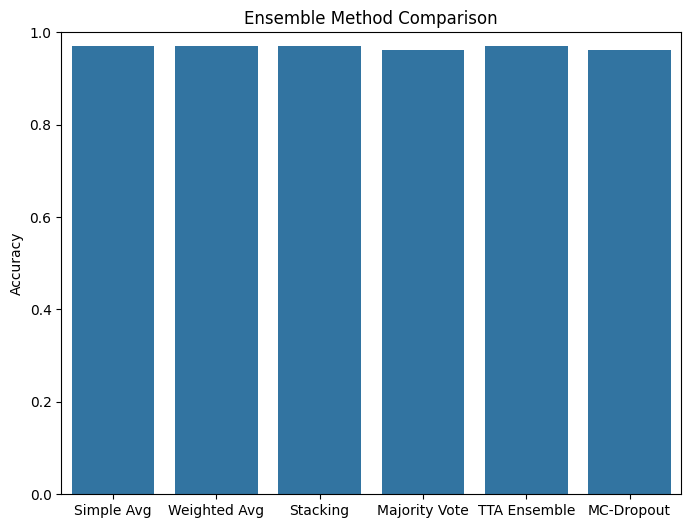

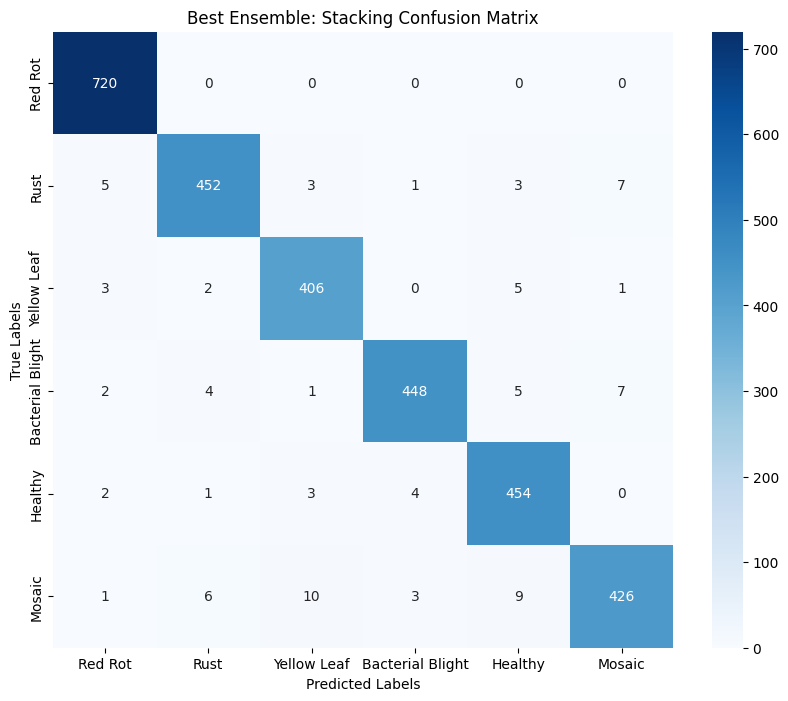

In [91]:
# Compare accuracies
acc_dict = {
    "Simple Avg": acc_avg,
    "Weighted Avg": acc_w,
    "Stacking": acc_stack,
    "Majority Vote": acc_vote,
    "TTA Ensemble": acc_tta,
    "MC-Dropout": acc_mc
}
plot_ensemble_accuracies(acc_dict)

# Confusion matrix for best-performing method (example: Stacking)
plot_confusion(y_true_avg, y_pred_avg, class_names, title="Best Ensemble: Stacking Confusion Matrix")

In [88]:
# -----------------------------
# Print all ensemble accuracies
# -----------------------------
print("=== Ensemble Accuracy Comparison ===")
print(f"Simple Average Ensemble       : {acc_avg:.4f}")
print(f"Weighted Average Ensemble     : {acc_w:.4f}")
print(f"Stacking Ensemble             : {acc_stack:.4f}")
print(f"Majority Voting Ensemble      : {acc_vote:.4f}")
print(f"TTA Ensemble                  : {acc_tta:.4f}")
print(f"MC-Dropout Ensemble           : {acc_mc:.4f}")
print("===================================")


=== Ensemble Accuracy Comparison ===
Simple Average Ensemble       : 0.9706
Weighted Average Ensemble     : 0.9693
Stacking Ensemble             : 0.9706
Majority Voting Ensemble      : 0.9613
TTA Ensemble                  : 0.9699
MC-Dropout Ensemble           : 0.9613


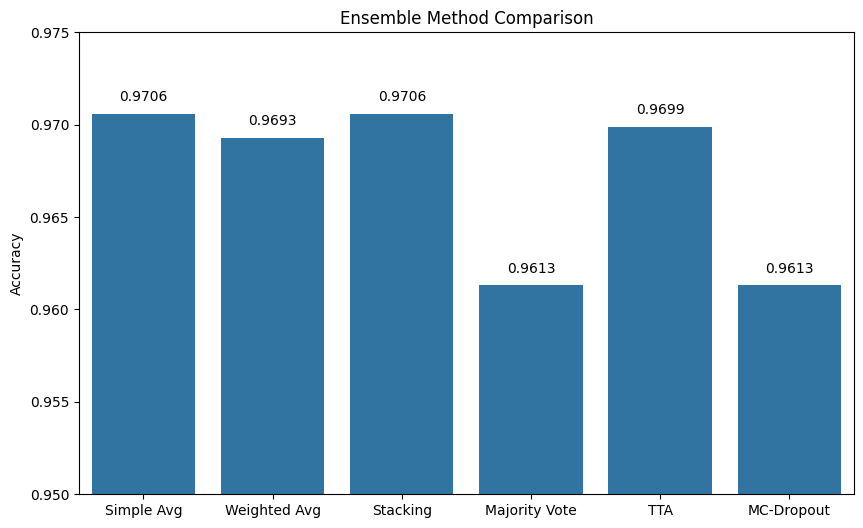

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

acc_dict = {
    "Simple Avg": 0.9706,
    "Weighted Avg": 0.9693,
    "Stacking": 0.9706,
    "Majority Vote": 0.9613,
    "TTA": 0.9699,
    "MC-Dropout": 0.9613
}

plt.figure(figsize=(10,6))
sns.barplot(x=list(acc_dict.keys()), y=list(acc_dict.values()))
plt.ylim(0.95, 0.975)  # zoom in to highlight differences
plt.ylabel("Accuracy")
plt.title("Ensemble Method Comparison")

# Add value labels on top of bars
for i, val in enumerate(acc_dict.values()):
    plt.text(i, val + 0.0005, f"{val:.4f}", ha='center', va='bottom', fontsize=10)

plt.show()

